### 08. PyTorch Model Deployment

## imports

In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular import data_setup, engine
from helper_functions import download_data, set_seeds, plot_loss_curves

c:\Users\yokes\anaconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 1. Getting data

In [4]:
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] data\pizza_steak_sushi_20_percent directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi_20_percent')

In [5]:
# Setup directory paths to train and test images
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

## 2. Creating an EffNetB2 feature extractor

In [6]:
# Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
# Get EffNetB2 transforms
effnetb2_transform = effnetb2_weights.transforms()
# Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)
# Freeze the base layers in the model (this will freeze all layers to begin with)
for params in effnetb2.parameters():
    params.requires_grad = False

In [7]:
# Check out EffNetB2 classifier head
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [8]:
# Update the classiffier
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3,inplace=True),
    nn.Linear(in_features=1408,
              out_features=3)
)

In [9]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

### 2.1 Creating a function to make an EffNetB2 feature extractor

In [10]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # 1, 2, 3. Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # 5. Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

In [11]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)

In [12]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

In [13]:
from torchinfo import summary

# Print EffNetB2 model summary (uncomment for full output) 
summary(effnetb2, 
         input_size=(1, 3, 224, 224),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 2.2 Creating DataLoaders for EffNetB2

In [14]:
# Setup DataLoaders
from going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                 test_dir=test_dir,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

### 2.3 Training EffNetB2 feature extractor

In [15]:
from going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set seeds for reproducibility and train the model
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                epochs=10,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9797 | train_acc: 0.5687 | test_loss: 0.7365 | test_acc: 0.9347


 10%|█         | 1/10 [00:12<01:49, 12.19s/it]

Epoch: 2 | train_loss: 0.7102 | train_acc: 0.8562 | test_loss: 0.5842 | test_acc: 0.9472


 20%|██        | 2/10 [00:21<01:24, 10.57s/it]

...

 80%|████████  | 8/10 [01:22<00:20, 10.04s/it]

Epoch: 9 | train_loss: 0.3734 | train_acc: 0.8979 | test_loss: 0.3100 | test_acc: 0.9256


 90%|█████████ | 9/10 [01:32<00:10, 10.08s/it]

Epoch: 10 | train_loss: 0.3648 | train_acc: 0.8646 | test_loss: 0.2782 | test_acc: 0.9625


100%|██████████| 10/10 [01:42<00:00, 10.25s/it]


### 2.4 Inspecting EffNetB2 loss curves

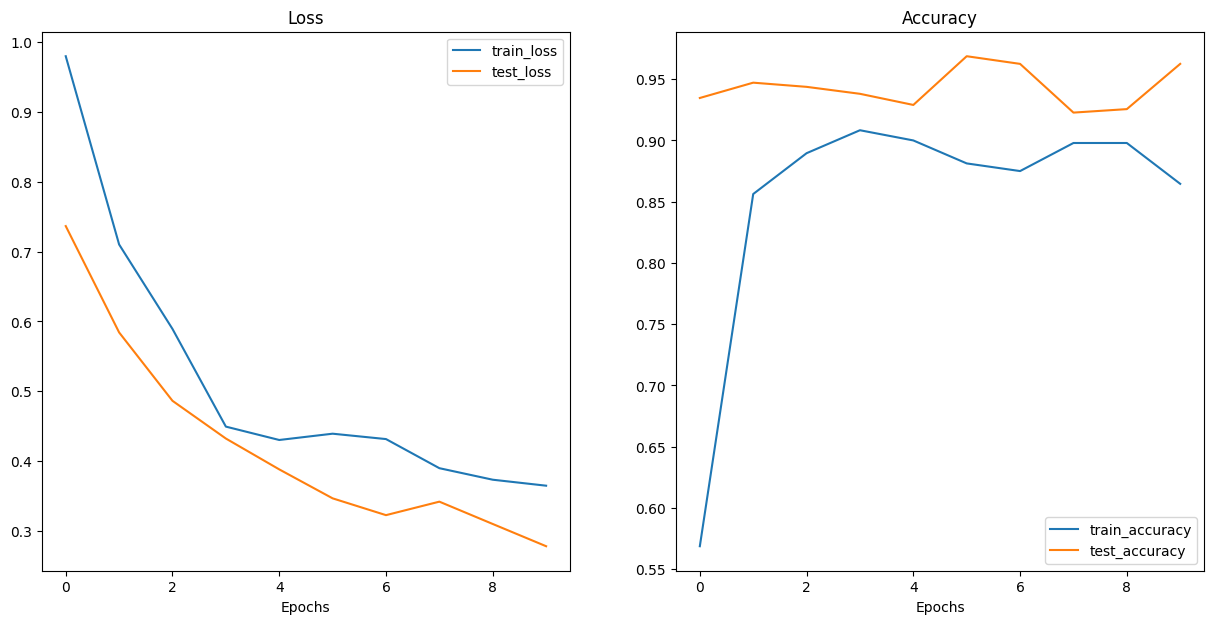

In [16]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

### 2.5 Saving EffNetB2 feature extractor

In [17]:
from going_modular import utils

# Save the model
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="08_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models\08_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


### 2.6 Checking the size of EffNetB2 feature extractor

In [18]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


### 2.7 Collecting EffNetB2 feature extractor stats

In [19]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params


7705221

In [20]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.27815687358379365,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29}

## 3. Making predictions with our trained model and timing them

### 3.1 Creating the function to make prediction across the test dataset

In [21]:
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer 
from tqdm.auto import tqdm
from typing import List,Dict

# Create the function to the return a list of dictionaries with sample, truth label, prediction, prediction probability and prediction time
def pred_and_store(paths: List[pathlib.Path],
                   model: torch.nn.Module,
                   transform: torchvision.transforms,
                   class_names: List[str],
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:
    
    #create the empty list to store the prediction dictionaries
    pred_list =[]

    # Loop through the path
    for path in tqdm(paths):

        # create the empty dictionary to store prediction information for each sample
        pred_dict = {}

        # Get the sample path and ground truth class name
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name

        #Start the prediction timer
        start_time = timer()

        # open the image using `PIL.Image.open(path)`
        img = Image.open(path)

        #Transform the image to be usable with a given model
        transformed_img = transform(img).unsqueeze(0).to(device)

        #eval mode
        model = model.to(device)
        model.eval()

        #Turn on the inference mode and predict the image class and probs
        with torch.inference_mode():
            pred_logit = model(transformed_img)
            pred_prob = torch.softmax(pred_logit,dim =1)
            pred_label = torch.argmax(pred_prob,dim=1)
            pred_class = class_names[pred_label.cpu()]

            # Add the pred prob , pred class in dict
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(),4)
            pred_dict["pred_class"] = pred_class

            #timer stop
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time,4)

        pred_dict["correct"] = class_name == pred_class

        pred_list.append(pred_dict)

    return pred_list


### 3.2 Making and timing predictions with EffNetB2

In [22]:
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1067986.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1315645.jpg')]

In [23]:
# Make predictions across test dataset with EffNetB2
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device="cpu") # make predictions on CPU 

100%|██████████| 150/150 [00:16<00:00,  9.19it/s]


In [24]:
effnetb2_test_pred_dicts[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9944,
  'pred_class': 'pizza',
  'time_for_pred': 0.1607,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.4829,
  'pred_class': 'pizza',
  'time_for_pred': 0.1005,
  'correct': True}]

In [25]:
import random
from pprint import pprint

random_5 = random.sample(effnetb2_test_pred_dicts, 5)

for i, item in enumerate(random_5, start=1):
    print(f"\nPrediction {i}")
    pprint(item)


Prediction 1
{'class_name': 'steak',
 'correct': True,
 'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/steak/1335842.jpg'),
 'pred_class': 'steak',
 'pred_prob': 0.6287,
 'time_for_pred': 0.0928}

Prediction 2
{'class_name': 'sushi',
 'correct': True,
 'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/sushi/593071.jpg'),
 'pred_class': 'sushi',
 'pred_prob': 0.8144,
 'time_for_pred': 0.0901}

Prediction 3
{'class_name': 'sushi',
 'correct': True,
 'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/sushi/2352914.jpg'),
 'pred_class': 'sushi',
 'pred_prob': 0.8408,
 'time_for_pred': 0.1746}

Prediction 4
{'class_name': 'pizza',
 'correct': True,
 'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/416067.jpg'),
 'pred_class': 'pizza',
 'pred_prob': 0.9557,
 'time_for_pred': 0.103}

Prediction 5
{'class_name': 'sushi',
 'correct': True,
 'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/sushi/3401466.jp

In [26]:
# Turn the test_pred_dicts into a DataFrame
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9944,pizza,0.1607,True
1,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.4829,pizza,0.1005,True
2,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9913,pizza,0.1053,True
3,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.6925,pizza,0.1066,True
4,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.7576,pizza,0.1028,True


In [27]:
# Check number of correct predictions
effnetb2_test_pred_df.correct.value_counts()

correct
True     144
False      6
Name: count, dtype: int64

In [28]:
# Find the average time per prediction 
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.1077 seconds


In [29]:
# Add EffNetB2 average prediction time to stats dictionary 
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.27815687358379365,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29,
 'time_per_pred_cpu': np.float64(0.1077)}

## 4. Bringing FoodVision Mini to life by creating a Gradio demo

In [30]:
import gradio as gr
print(f"Gradio version: {gr.__version__}")


Gradio version: 6.14.0


### 4.1 Creating a function to map our inputs and outputs

In [31]:
# Put EffNetB2 on CPU
effnetb2.to("cpu") 

# Check the device
next(iter(effnetb2.parameters())).device

device(type='cpu')

In [32]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

In [33]:
import random
from PIL import Image

# Get a list of all test image filepaths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

# Randomly select a test image path
random_image_path = random.sample(test_data_paths, k=1)[0]

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] Predicting on image at path: data\pizza_steak_sushi_20_percent\test\pizza\724290.jpg

Prediction label and probability dictionary: 
{'pizza': 0.6728354096412659, 'steak': 0.2196684032678604, 'sushi': 0.10749620199203491}
Prediction time: 0.09188 seconds


### 4.2 Creating a list of example images

In [34]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data\\pizza_steak_sushi_20_percent\\test\\pizza\\3785667.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\steak\\100274.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\steak\\552171.jpg']]

### 4.3 Building a Gradio interface

In [35]:
import gradio as gr

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700;900&family=DM+Sans:wght@300;400;500&display=swap');

:root {
    --bg: #0f0d0b;
    --surface: #1a1714;
    --card: #221f1b;
    --border: #2e2a25;
    --accent: #e8602c;
    --accent2: #f5a623;
    --text: #f0ebe4;
    --muted: #8a8278;
    --radius: 16px;
}

body, .gradio-container {
    background: var(--bg) !important;
    font-family: 'DM Sans', sans-serif !important;
    color: var(--text) !important;
}

footer { display: none !important; }

#header {
    background: linear-gradient(135deg, #1a1714 0%, #2a1f14 50%, #1a1714 100%);
    border: 1px solid var(--border);
    border-radius: var(--radius);
    padding: 36px 40px 28px;
    margin-bottom: 24px;
    position: relative;
    overflow: hidden;
}
#header::before {
    content: '';
    position: absolute;
    top: -60px; right: -60px;
    width: 220px; height: 220px;
    background: radial-gradient(circle, rgba(232,96,44,0.18) 0%, transparent 70%);
    border-radius: 50%;
}
#header h1 {
    font-family: 'Playfair Display', serif !important;
    font-size: 2.8rem !important;
    font-weight: 900 !important;
    color: var(--text) !important;
    margin: 0 0 8px !important;
    line-height: 1.1 !important;
}
#header p {
    color: var(--muted) !important;
    font-size: 0.95rem !important;
    font-weight: 300 !important;
    margin: 0 !important;
    line-height: 1.6;
}

.badge {
    display: inline-block;
    background: rgba(232,96,44,0.15);
    color: var(--accent);
    border: 1px solid rgba(232,96,44,0.3);
    border-radius: 999px;
    font-size: 0.7rem;
    font-weight: 500;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    padding: 3px 10px;
    margin-bottom: 16px;
}

.section-label {
    font-size: 0.7rem !important;
    font-weight: 500 !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
    color: var(--muted) !important;
    margin-bottom: 10px !important;
}

.panel {
    background: var(--card) !important;
    border: 1px solid var(--border) !important;
    border-radius: var(--radius) !important;
}

.upload-box .wrap {
    background: var(--surface) !important;
    border: 2px dashed var(--border) !important;
    border-radius: var(--radius) !important;
    min-height: 260px !important;
    transition: border-color 0.2s ease;
}
.upload-box .wrap:hover { border-color: var(--accent) !important; }

#predict-btn {
    background: linear-gradient(135deg, var(--accent) 0%, #c94e20 100%) !important;
    border: none !important;
    border-radius: 12px !important;
    color: #fff !important;
    font-size: 1rem !important;
    font-weight: 500 !important;
    padding: 14px !important;
    width: 100% !important;
    cursor: pointer !important;
    box-shadow: 0 4px 20px rgba(232,96,44,0.3) !important;
    transition: opacity 0.2s, transform 0.1s !important;
}
#predict-btn:hover { opacity: 0.9 !important; transform: translateY(-1px) !important; }

#clear-btn {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 12px !important;
    color: var(--muted) !important;
    font-size: 0.9rem !important;
    padding: 12px !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: border-color 0.2s, color 0.2s !important;
}
#clear-btn:hover { border-color: var(--muted) !important; color: var(--text) !important; }

.label-output .bar {
    background: linear-gradient(90deg, var(--accent) 0%, var(--accent2) 100%) !important;
    border-radius: 4px !important;
    height: 8px !important;
}

.timing-box input {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 10px !important;
    color: var(--accent2) !important;
    font-family: 'Playfair Display', serif !important;
    font-size: 1.6rem !important;
    text-align: center !important;
    padding: 14px !important;
}

#footer-strip {
    margin-top: 20px;
    padding: 16px 20px;
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 12px;
    font-size: 0.82rem;
    color: var(--muted);
}
#footer-strip a { color: var(--accent2) !important; text-decoration: none; }
"""

with gr.Blocks(css=custom_css, title="FoodVision Mini") as demo:

    gr.HTML("""
    <div id="header">
        <span style="font-size:2rem;display:block;margin-bottom:12px">🍕 🥩 🍣</span>
        <div class="badge">EfficientNetB2 · Computer Vision</div>
        <h1>FoodVision Mini</h1>
        <p>Drop any food photo and the model will classify it as pizza, steak, or sushi — with confidence scores and inference timing.</p>
    </div>
    """)

    with gr.Row(equal_height=False):

        with gr.Column(scale=1, elem_classes="panel"):
            gr.HTML('<p class="section-label">📸 Upload Image</p>')
            image_input = gr.Image(type="pil", label="", show_label=False, elem_classes="upload-box")
            gr.HTML('<p class="section-label" style="margin-top:16px">⚡ Quick Examples</p>')
            gr.Examples(examples=example_list, inputs=image_input)

        with gr.Column(scale=1):
            with gr.Row():
                clear_btn   = gr.Button("✕  Clear",   elem_id="clear-btn")
                predict_btn = gr.Button("Classify →", elem_id="predict-btn")

            gr.HTML('<p class="section-label" style="margin-top:20px">📊 Predictions</p>')
            label_output = gr.Label(num_top_classes=3, label="", show_label=False, elem_classes="label-output panel")

            gr.HTML('<p class="section-label" style="margin-top:16px">⏱ Inference Time</p>')
            time_output = gr.Number(label="", show_label=False, elem_classes="timing-box panel", precision=4)

    gr.HTML("""
    <div id="footer-strip">
        📖 &nbsp;Tutorial: <a href="https://www.learnpytorch.io/09_pytorch_model_deployment/" target="_blank">
        08. PyTorch Model Deployment — learnpytorch.io</a>
    </div>
    """)

    predict_btn.click(fn=predict, inputs=image_input, outputs=[label_output, time_output])
    clear_btn.click(fn=lambda: (None, None, None), inputs=[], outputs=[image_input, label_output, time_output])

demo.launch(debug=False, share=False)

C:\Users\yokes\AppData\Local\Temp\ipykernel_30632\743709320.py:154: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="FoodVision Mini") as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 5.Turning our FoodVision Mini Gradio Demo into a deployable app

### 5.1 What is Hugging Face Spaces?

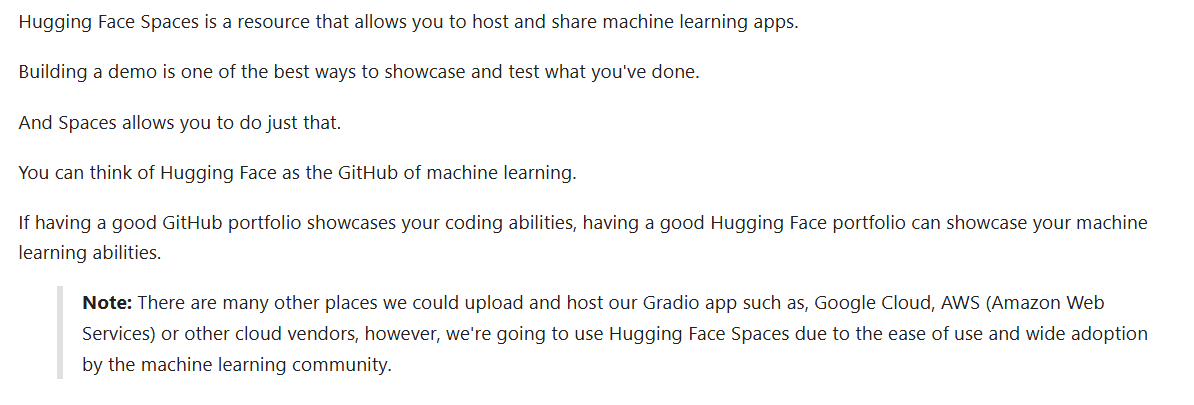

### 5.2 Deployed Gradio app structure
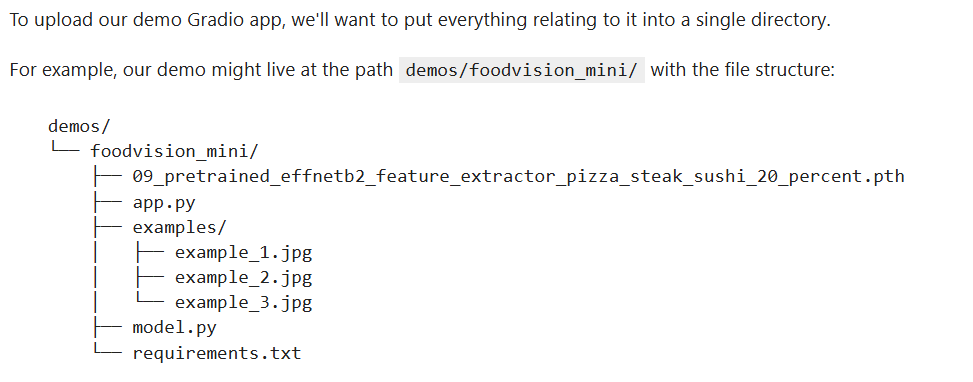

### 5.3  Creating a demos folder to store our FoodVision Mini app files

In [36]:
import shutil
from pathlib import Path

# Create FoodVision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# Remove files that might already exist there and create new directory
if foodvision_mini_demo_path.exists():
    shutil.rmtree(foodvision_mini_demo_path)
# If the file doesn't exist, create it anyway
foodvision_mini_demo_path.mkdir(parents=True, 
                                exist_ok=True)
    
# Check what's in the folder
!ls demos/foodvision_mini/

'ls' is not recognized as an internal or external command,
operable program or batch file.


### 5.4 Creating a folder of example images to use with our FoodVision Mini demo

In [37]:
import shutil
from pathlib import Path

# 1. Create an examples directory
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents=True, exist_ok=True)

# 2. Collect three random test dataset image paths
foodvision_mini_examples = [Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')]

# 3. Copy the three random images to the examples directory
for example in foodvision_mini_examples:
    destination = foodvision_mini_examples_path / example.name
    print(f"[INFO] Copying {example} to {destination}")
    shutil.copy2(src=example, dst=destination)

[INFO] Copying data\pizza_steak_sushi_20_percent\test\sushi\592799.jpg to demos\foodvision_mini\examples\592799.jpg
[INFO] Copying data\pizza_steak_sushi_20_percent\test\steak\3622237.jpg to demos\foodvision_mini\examples\3622237.jpg
[INFO] Copying data\pizza_steak_sushi_20_percent\test\pizza\2582289.jpg to demos\foodvision_mini\examples\2582289.jpg


In [38]:
import os

# Get example filepaths in a list of lists
example_list = [["examples/" + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/2582289.jpg'], ['examples/3622237.jpg'], ['examples/592799.jpg']]

### 5.5 Moving our trained EffNetB2 model to our FoodVision Mini demo directory

In [39]:
import shutil

# Create a source path for our target model
effnetb2_foodvision_mini_model_path = "models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"

# Create a destination path for our target model 
effnetb2_foodvision_mini_model_destination = foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.split("/")[1]

# Try to move the file
try:
    print(f"[INFO] Attempting to move {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")
    
    # Move the model
    shutil.move(src=effnetb2_foodvision_mini_model_path, 
                dst=effnetb2_foodvision_mini_model_destination)
    
    print(f"[INFO] Model move complete.")

# If the model has already been moved, check if it exists
except:
    print(f"[INFO] No model found at {effnetb2_foodvision_mini_model_path}, perhaps its already been moved?")
    print(f"[INFO] Model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to move models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth to demos\foodvision_mini\09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
[INFO] Model move complete.


### 5.6  Turning our EffNetB2 model into a Python script (model.py)

In [40]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

Writing demos/foodvision_mini/model.py


### 5.7 Turning our FoodVision Mini Gradio app into a Python script (app.py)

In [41]:
%%writefile demos/foodvision_mini/app.py
### 1. Imports and class names setup ### 
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ["pizza", "steak", "sushi"]

### 2. Model and transforms preparation ###

# Create EffNetB2 model
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=3, # len(class_names) would also work
)

# Load saved weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

### 3. Predict function ###

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

### 4. Gradio app ###

# Create title, description and article strings
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
import gradio as gr

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700;900&family=DM+Sans:wght@300;400;500&display=swap');

:root {
    --bg: #0f0d0b;
    --surface: #1a1714;
    --card: #221f1b;
    --border: #2e2a25;
    --accent: #e8602c;
    --accent2: #f5a623;
    --text: #f0ebe4;
    --muted: #8a8278;
    --radius: 16px;
}

body, .gradio-container {
    background: var(--bg) !important;
    font-family: 'DM Sans', sans-serif !important;
    color: var(--text) !important;
}

footer { display: none !important; }

#header {
    background: linear-gradient(135deg, #1a1714 0%, #2a1f14 50%, #1a1714 100%);
    border: 1px solid var(--border);
    border-radius: var(--radius);
    padding: 36px 40px 28px;
    margin-bottom: 24px;
    position: relative;
    overflow: hidden;
}
#header::before {
    content: '';
    position: absolute;
    top: -60px; right: -60px;
    width: 220px; height: 220px;
    background: radial-gradient(circle, rgba(232,96,44,0.18) 0%, transparent 70%);
    border-radius: 50%;
}
#header h1 {
    font-family: 'Playfair Display', serif !important;
    font-size: 2.8rem !important;
    font-weight: 900 !important;
    color: var(--text) !important;
    margin: 0 0 8px !important;
    line-height: 1.1 !important;
}
#header p {
    color: var(--muted) !important;
    font-size: 0.95rem !important;
    font-weight: 300 !important;
    margin: 0 !important;
    line-height: 1.6;
}

.badge {
    display: inline-block;
    background: rgba(232,96,44,0.15);
    color: var(--accent);
    border: 1px solid rgba(232,96,44,0.3);
    border-radius: 999px;
    font-size: 0.7rem;
    font-weight: 500;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    padding: 3px 10px;
    margin-bottom: 16px;
}

.section-label {
    font-size: 0.7rem !important;
    font-weight: 500 !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
    color: var(--muted) !important;
    margin-bottom: 10px !important;
}

.panel {
    background: var(--card) !important;
    border: 1px solid var(--border) !important;
    border-radius: var(--radius) !important;
}

.upload-box .wrap {
    background: var(--surface) !important;
    border: 2px dashed var(--border) !important;
    border-radius: var(--radius) !important;
    min-height: 260px !important;
    transition: border-color 0.2s ease;
}
.upload-box .wrap:hover { border-color: var(--accent) !important; }

#predict-btn {
    background: linear-gradient(135deg, var(--accent) 0%, #c94e20 100%) !important;
    border: none !important;
    border-radius: 12px !important;
    color: #fff !important;
    font-size: 1rem !important;
    font-weight: 500 !important;
    padding: 14px !important;
    width: 100% !important;
    cursor: pointer !important;
    box-shadow: 0 4px 20px rgba(232,96,44,0.3) !important;
    transition: opacity 0.2s, transform 0.1s !important;
}
#predict-btn:hover { opacity: 0.9 !important; transform: translateY(-1px) !important; }

#clear-btn {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 12px !important;
    color: var(--muted) !important;
    font-size: 0.9rem !important;
    padding: 12px !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: border-color 0.2s, color 0.2s !important;
}
#clear-btn:hover { border-color: var(--muted) !important; color: var(--text) !important; }

.label-output .bar {
    background: linear-gradient(90deg, var(--accent) 0%, var(--accent2) 100%) !important;
    border-radius: 4px !important;
    height: 8px !important;
}

.timing-box input {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 10px !important;
    color: var(--accent2) !important;
    font-family: 'Playfair Display', serif !important;
    font-size: 1.6rem !important;
    text-align: center !important;
    padding: 14px !important;
}

#footer-strip {
    margin-top: 20px;
    padding: 16px 20px;
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 12px;
    font-size: 0.82rem;
    color: var(--muted);
}
#footer-strip a { color: var(--accent2) !important; text-decoration: none; }
"""

with gr.Blocks(css=custom_css, title="FoodVision Mini") as demo:

    gr.HTML("""
    <div id="header">
        <span style="font-size:2rem;display:block;margin-bottom:12px">🍕 🥩 🍣</span>
        <div class="badge">EfficientNetB2 · Computer Vision</div>
        <h1>FoodVision Mini</h1>
        <p>Drop any food photo and the model will classify it as pizza, steak, or sushi — with confidence scores and inference timing.</p>
    </div>
    """)

    with gr.Row(equal_height=False):

        with gr.Column(scale=1, elem_classes="panel"):
            gr.HTML('<p class="section-label">📸 Upload Image</p>')
            image_input = gr.Image(type="pil", label="", show_label=False, elem_classes="upload-box")
            gr.HTML('<p class="section-label" style="margin-top:16px">⚡ Quick Examples</p>')
            gr.Examples(examples=example_list, inputs=image_input)

        with gr.Column(scale=1):
            with gr.Row():
                clear_btn   = gr.Button("✕  Clear",   elem_id="clear-btn")
                predict_btn = gr.Button("Classify →", elem_id="predict-btn")

            gr.HTML('<p class="section-label" style="margin-top:20px">📊 Predictions</p>')
            label_output = gr.Label(num_top_classes=3, label="", show_label=False, elem_classes="label-output panel")

            gr.HTML('<p class="section-label" style="margin-top:16px">⏱ Inference Time</p>')
            time_output = gr.Number(label="", show_label=False, elem_classes="timing-box panel", precision=4)

    gr.HTML("""
    <div id="footer-strip">
        📖 &nbsp;Tutorial: <a href="https://www.learnpytorch.io/09_pytorch_model_deployment/" target="_blank">
        08. PyTorch Model Deployment — learnpytorch.io</a>
    </div>
    """)

    predict_btn.click(fn=predict, inputs=image_input, outputs=[label_output, time_output])
    clear_btn.click(fn=lambda: (None, None, None), inputs=[], outputs=[image_input, label_output, time_output])

demo.launch()

Writing demos/foodvision_mini/app.py


### 5.8 Creating a requirements file for FoodVision Mini (requirements.txt)

In [45]:
%%writefile demos/foodvision_mini/requirements.txt
torch
torchvision
gradio

Writing demos/foodvision_mini/requirements.txt
